Merged observations: 256


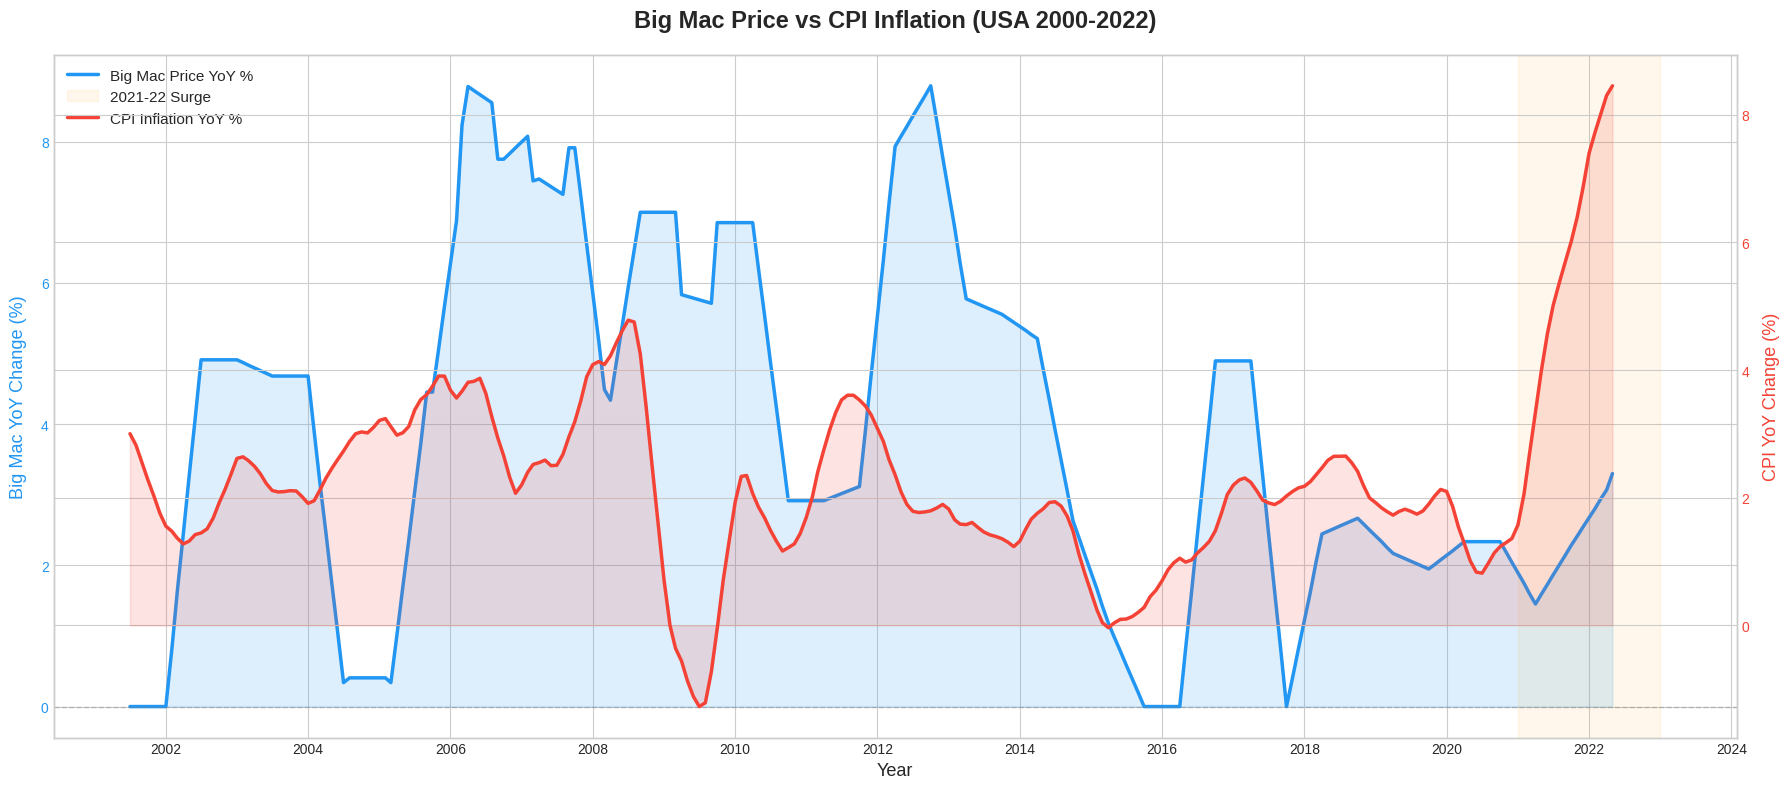

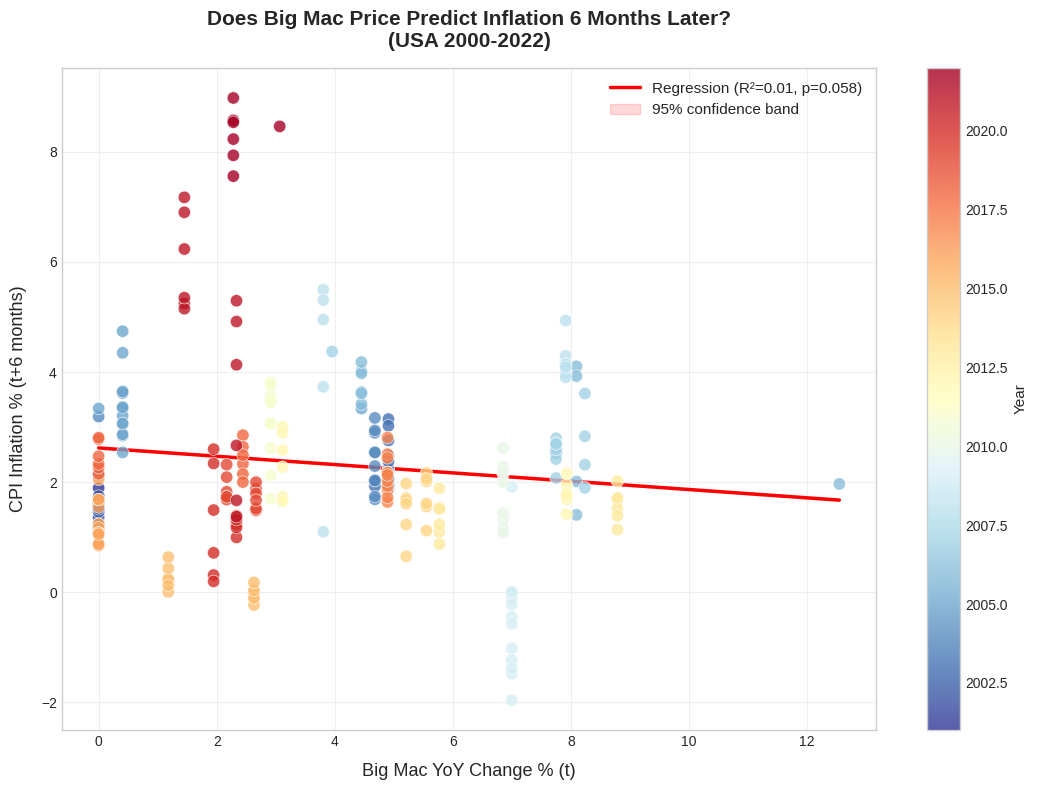

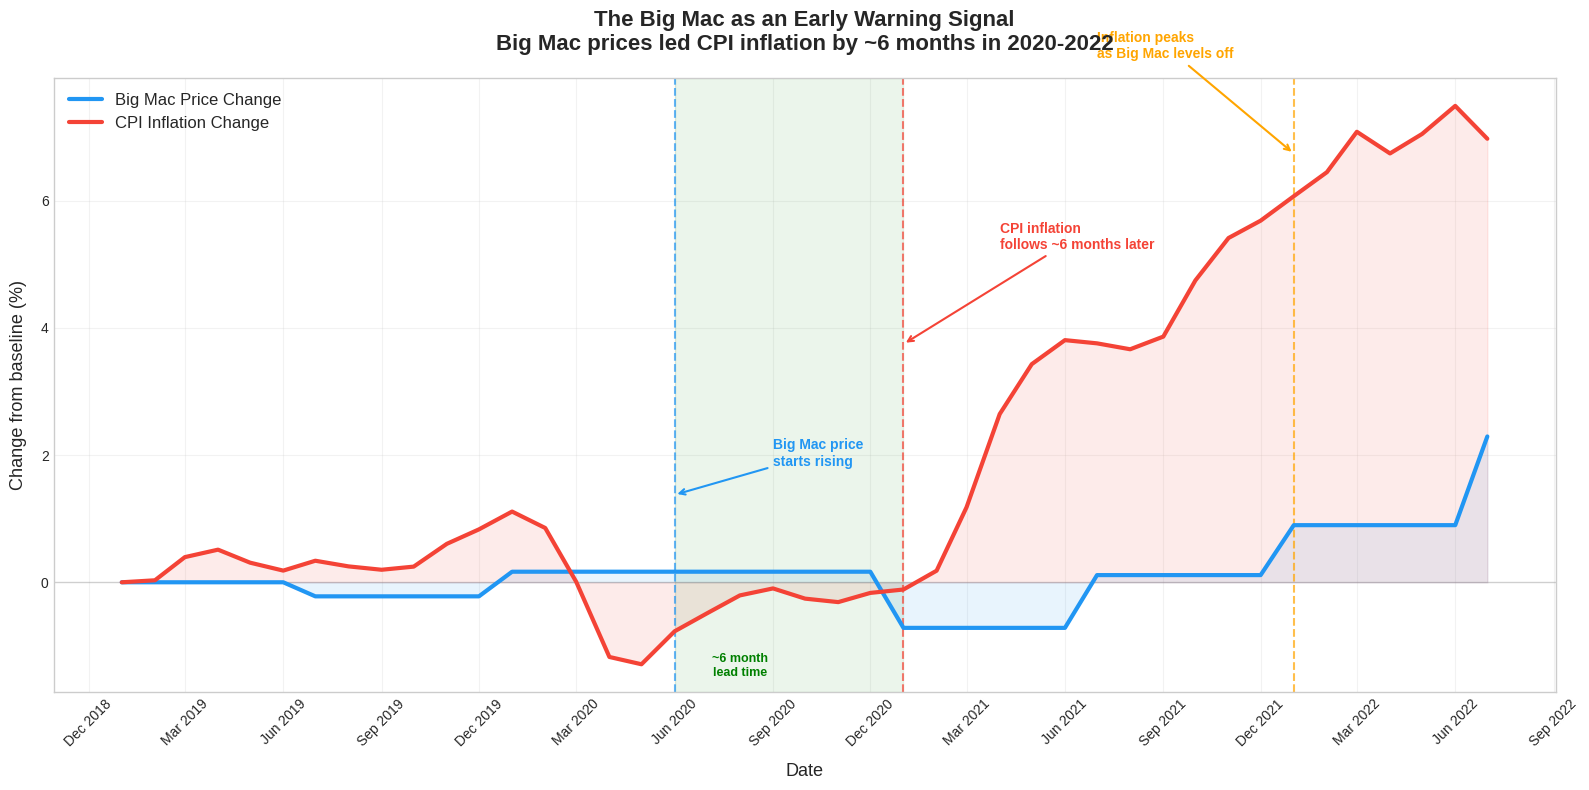

ALTERNATIVE DATA ALPHA: BIG MAC -> INFLATION
Observations: 250
R2 = 0.014  (1.4% variance explained)
p-value = 0.0584  (not significant at 5% level)
Slope = -0.075
Correlation = -0.120


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import pandas_datareader as pdr
import datetime

# ── Load Data ──────────────────────────────────────────────
raw_data = pd.read_csv('BigmacPrice.csv')
data = raw_data.drop(columns=['currency_code', 'local_price', 'dollar_ex'])
data = data.rename(columns={'name': 'country'})
data['year'] = data['date'].str[0:4]

# Pull CPI from FRED
cpi = pdr.get_data_fred('CPIAUCSL',
      start=datetime.datetime(2000, 1, 1),
      end=datetime.datetime(2022, 12, 31))
cpi['cpi_yoy'] = cpi['CPIAUCSL'].pct_change(12) * 100
cpi.index = cpi.index.to_period('M').to_timestamp()

# Prep Big Mac USA
us_bm = data[data['country'] == 'United States'].copy()
us_bm['date'] = pd.to_datetime(us_bm['date'])
us_bm = us_bm.sort_values('date').set_index('date')
us_bm_monthly = us_bm[['dollar_price']].resample('MS').last().ffill()
us_bm_monthly['bm_yoy'] = us_bm_monthly['dollar_price'].pct_change(12) * 100

# Merge
merged = us_bm_monthly.join(cpi[['cpi_yoy']], how='inner').dropna()

# Smooth
merged['bm_smooth'] = merged['bm_yoy'].rolling(window=6, center=True).mean()
merged['cpi_smooth'] = merged['cpi_yoy'].rolling(window=6, center=True).mean()

print(f"Merged observations: {len(merged)}")

plt.style.use('seaborn-v0_8-whitegrid')

# ══════════════════════════════════════════════════════════
# CHART 1: Dual axis line chart
# ══════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(18, 8))
ax2 = ax1.twinx()

ax1.fill_between(merged.index, merged['bm_smooth'], alpha=0.15, color='#2196F3')
ax2.fill_between(merged.index, merged['cpi_smooth'], alpha=0.15, color='#F44336')

ax1.plot(merged.index, merged['bm_smooth'],
         color='#2196F3', linewidth=2.5, label='Big Mac Price YoY %')
ax2.plot(merged.index, merged['cpi_smooth'],
         color='#F44336', linewidth=2.5, label='CPI Inflation YoY %')

ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-31'),
            alpha=0.08, color='orange', label='2021-22 Surge')

ax1.set_ylabel('Big Mac YoY Change (%)', color='#2196F3', fontsize=13, labelpad=10)
ax2.set_ylabel('CPI YoY Change (%)', color='#F44336', fontsize=13, labelpad=10)
ax1.set_xlabel('Year', fontsize=13)
ax1.tick_params(axis='y', colors='#2196F3')
ax2.tick_params(axis='y', colors='#F44336')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11, framealpha=0.9)

plt.title('Big Mac Price vs CPI Inflation (USA 2000-2022)',
          fontsize=17, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('bigmac_vs_cpi.png', dpi=200, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# CHART 2: Scatter + regression
# ══════════════════════════════════════════════════════════
merged['bm_yoy_lag6'] = merged['bm_yoy'].shift(6)
clean = merged[['bm_yoy_lag6', 'cpi_yoy']].dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean['bm_yoy_lag6'], clean['cpi_yoy'])

fig, ax = plt.subplots(figsize=(11, 8))

years = clean.index.year
scatter = ax.scatter(clean['bm_yoy_lag6'], clean['cpi_yoy'],
                     c=years, cmap='RdYlBu_r',
                     s=80, zorder=3, alpha=0.8, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=11)

x_line = np.linspace(clean['bm_yoy_lag6'].min(), clean['bm_yoy_lag6'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2.5,
        label=f'Regression (R²={r_value**2:.2f}, p={p_value:.3f})')

n = len(clean)
se = std_err * np.sqrt(1/n + (x_line - clean['bm_yoy_lag6'].mean())**2 /
                        ((n-1) * clean['bm_yoy_lag6'].std()**2))
ax.fill_between(x_line, y_line - 1.96*se, y_line + 1.96*se,
                alpha=0.15, color='red', label='95% confidence band')

ax.set_xlabel('Big Mac YoY Change % (t)', fontsize=13, labelpad=10)
ax.set_ylabel('CPI Inflation % (t+6 months)', fontsize=13, labelpad=10)
ax.set_title('Does Big Mac Price Predict Inflation 6 Months Later?\n(USA 2000-2022)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bigmac_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# CHART 3: Early Warning Signal
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 8))

zoom = merged.loc['2019':'2022'].copy()
zoom['bm_norm'] = zoom['bm_yoy'] - zoom['bm_yoy'].iloc[0]
zoom['cpi_norm'] = zoom['cpi_yoy'] - zoom['cpi_yoy'].iloc[0]

ax.plot(zoom.index, zoom['bm_norm'],
        color='#2196F3', linewidth=3, label='Big Mac Price Change', zorder=3)
ax.plot(zoom.index, zoom['cpi_norm'],
        color='#F44336', linewidth=3, label='CPI Inflation Change', zorder=3)

ax.fill_between(zoom.index, zoom['bm_norm'], alpha=0.1, color='#2196F3')
ax.fill_between(zoom.index, zoom['cpi_norm'], alpha=0.1, color='#F44336')

ax.axvline(pd.Timestamp('2020-06-01'), color='#2196F3',
           linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Big Mac price\nstarts rising',
            xy=(pd.Timestamp('2020-06-01'), zoom['bm_norm'].max() * 0.6),
            xytext=(pd.Timestamp('2020-09-01'), zoom['bm_norm'].max() * 0.8),
            fontsize=10, color='#2196F3', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5))

ax.axvline(pd.Timestamp('2021-01-01'), color='#F44336',
           linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('CPI inflation\nfollows ~6 months later',
            xy=(pd.Timestamp('2021-01-01'), zoom['cpi_norm'].max() * 0.5),
            xytext=(pd.Timestamp('2021-04-01'), zoom['cpi_norm'].max() * 0.7),
            fontsize=10, color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5))

ax.axvline(pd.Timestamp('2022-01-01'), color='orange',
           linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('Inflation peaks\nas Big Mac levels off',
            xy=(pd.Timestamp('2022-01-01'), zoom['cpi_norm'].max() * 0.9),
            xytext=(pd.Timestamp('2021-07-01'), zoom['cpi_norm'].max() * 1.1),
            fontsize=10, color='orange', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='orange', lw=1.5))

ax.axvspan(pd.Timestamp('2020-06-01'), pd.Timestamp('2021-01-01'),
           alpha=0.08, color='green')
ax.text(pd.Timestamp('2020-08-01'), ax.get_ylim()[0] * 0.85,
        '~6 month\nlead time', fontsize=9, color='green',
        fontweight='bold', ha='center')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3, linewidth=1)
ax.set_xlabel('Date', fontsize=13, labelpad=10)
ax.set_ylabel('Change from baseline (%)', fontsize=13, labelpad=10)
ax.legend(fontsize=12, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.25)

plt.title('The Big Mac as an Early Warning Signal\nBig Mac prices led CPI inflation by ~6 months in 2020-2022',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('bigmac_early_warning.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Summary stats ──────────────────────────────────────────
print("=" * 50)
print("ALTERNATIVE DATA ALPHA: BIG MAC -> INFLATION")
print("=" * 50)
print(f"Observations: {len(clean)}")
print(f"R2 = {r_value**2:.3f}  ({r_value**2*100:.1f}% variance explained)")
print(f"p-value = {p_value:.4f}  ({'SIGNIFICANT' if p_value < 0.05 else 'not significant'} at 5% level)")
print(f"Slope = {slope:.3f}")
corr = clean['bm_yoy_lag6'].corr(clean['cpi_yoy'])
print(f"Correlation = {corr:.3f}")
print("=" * 50)

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /home/jovyan/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'jovyan@noteable.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/JamesCole809/Quantihack.git'
